<a href="https://colab.research.google.com/github/Chi254/P1_personal-loan-modeling/blob/main/02_modeling_personal_loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Modeling Objective

### Business Question

Can we use customer information to predict whether a customer
will accept a personal loan offer?

### Target

`personal_loan`

- 0: Customer did not accept the personal loan
- 1: Customer accepted the personal loan

### Modeling Objective

The objective is to build and evaluate classification models that
can distinguish between customers who are likely and unlikely to
accept a personal loan.

Because the target variable is imbalanced, model performance will
not be evaluated using accuracy alone.

In [99]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
import pandas as pd

file_path = "/content/drive/MyDrive/P1_Supervised/DATA/Bank_Personal_Loan_Modelling.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.lower()

df.head()

,id,age,experience,income,zip code,family,ccavg,education,mortgage,personal loan,securities account,cd account,online,creditcard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [101]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='personal loan')
y = df['personal loan']

In [102]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [103]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
personal loan
0    0.904
1    0.096
Name: proportion, dtype: float64

Validation target distribution:
personal loan
0    0.904
1    0.096
Name: proportion, dtype: float64

Test target distribution:
personal loan
0    0.904
1    0.096
Name: proportion, dtype: float64


The target variable is highly imbalanced, so stratified splitting is
used to preserve a similar class distribution across the training,
validation, and test sets.

##2. BASELINE MODEL

With the simplest model, how well can it evaluate?

In [104]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_val, baseline_pred))
print("Precision:", precision_score(y_val, baseline_pred, zero_division=0))
print("Recall:", recall_score(y_val, baseline_pred, zero_division=0))
print("F1:", f1_score(y_val, baseline_pred, zero_division=0))

Accuracy: 0.904
Precision: 0.0
Recall: 0.0
F1: 0.0


- Accuracy is too high due to data imbalanced.
- Precision, Recall, F1 all resulted in 0.
=> With this matter, accuracy is not a good indicator and other model needed to be applied to evaluate.

In [106]:
numeric_features = [
    'age',
    'experience',
    'income',
    'ccavg',
    'mortgage'
]

categorical_features = [
    'family',
    'education',
    'securities account',
    'cd account',
    'online',
    'creditcard'
]

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)


##2.1: Logistic Regression


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [109]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'experience',
                                                   'income', 'ccavg',
                                                   'mortgage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['family', 'education',
                                                   'securities account',
                                                   'cd account', 'online',
                                                   'creditcard'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [110]:
y_val_pred = logistic_model.predict(X_val)

In [111]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

In [112]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("Logistic Regression Model Metrics on Validation Set:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("F1-score:", f1_score(y_val, y_val_pred, zero_division=0))
print("ROC AUC Score:", roc_auc_score(y_val, y_val_prob))

Logistic Regression Model Metrics on Validation Set:
Accuracy: 0.962
Precision: 0.8717948717948718
Recall: 0.7083333333333334
F1-score: 0.7816091954022989
ROC AUC Score: 0.9642676069321534



Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       904
           1       0.87      0.71      0.78        96

    accuracy                           0.96      1000
   macro avg       0.92      0.85      0.88      1000
weighted avg       0.96      0.96      0.96      1000



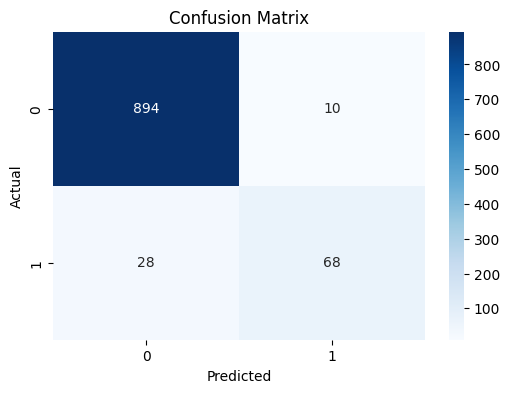

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nClassification Report:\n", classification_report(y_val, y_val_pred, zero_division=0))

cm = confusion_matrix(y_val, y_val_pred);
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [114]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print("Logistic Regression Model Metrics on Validation Set:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("F1-score:", f1_score(y_val, y_val_pred, zero_division=0))
print("ROC AUC Score:", roc_auc_score(y_val, y_val_prob))

Logistic Regression Model Metrics on Validation Set:
Accuracy: 0.962
Precision: 0.8717948717948718
Recall: 0.7083333333333334
F1-score: 0.7816091954022989
ROC AUC Score: 0.9642676069321534


In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model, X_data, y_data):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    return {
        'Accuracy': accuracy_score(y_data, y_pred),
        'Precision': precision_score(y_data, y_pred, zero_division=0),
        'Recall': recall_score(y_data, y_pred, zero_division=0),
        'F1': f1_score(y_data, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_data, y_prob),
        'PR-AUC': average_precision_score(y_data, y_prob)
    }

In [116]:
logistic_results = evaluate_model(
    logistic_model,
    X_val,
    y_val
)

logistic_results

{'Accuracy': 0.962,
 'Precision': 0.8717948717948718,
 'Recall': 0.7083333333333334,
 'F1': 0.7816091954022989,
 'ROC-AUC': np.float64(0.9642676069321534),
 'PR-AUC': np.float64(0.8553128074690274)}

##2.2: Decision Tree

In [117]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

In [118]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'experience',
                                                   'income', 'ccavg',
                                                   'mortgage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['family', 'education',
                                                   'securities account',
                                                   'cd account', 'online',
                                                   'creditcard'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [119]:
tree_results = evaluate_model(
    tree_model,
    X_val,
    y_val
)

tree_results

{'Accuracy': 0.98,
 'Precision': 0.9222222222222223,
 'Recall': 0.8645833333333334,
 'F1': 0.8924731182795699,
 'ROC-AUC': np.float64(0.9775765117994101),
 'PR-AUC': np.float64(0.9151645406857178)}

##2.3: Random Forest

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [121]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'experience',
                                                   'income', 'ccavg',
                                                   'mortgage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['family', 'education',
                                                   'securities account',
                                                   'cd account', 'online',
                                                   'creditcard'])])),
                ('model',
                 RandomForestClassifier(max_depth=8, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [122]:
rf_results = evaluate_model(
    rf_model,
    X_val,
    y_val
)

rf_results

{'Accuracy': 0.983,
 'Precision': 0.9876543209876543,
 'Recall': 0.8333333333333334,
 'F1': 0.903954802259887,
 'ROC-AUC': np.float64(0.9976378134218289),
 'PR-AUC': np.float64(0.9797462736348603)}

2.4. Model comparion


In [123]:
import pandas as pd

baseline_results = evaluate_model(
    baseline,
    X_val,
    y_val
)

results = pd.DataFrame({
    'Baseline': baseline_results,
    'Logistic Regression': logistic_results,
    'Decision Tree': tree_results,
    'Random Forest': rf_results
}).T

results

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline,0.904,0.000000,0.000000,0.000000,0.500000,0.096000
Logistic Regression,0.962,0.871795,0.708333,0.781609,0.964268,0.855313
Decision Tree,0.980,0.922222,0.864583,0.892473,0.977577,0.915165
Random Forest,0.983,0.987654,0.833333,0.903955,0.997638,0.979746


##3. Validation

Model can make wrong predictions as:
1. Predicting a person will buy a loan but he actually doesn't.(Loss of Resource)
2. Predicting a person will not buy a loan but he actually does.(Loss of Opportunity)

Which case is more important?
=> The whole purpose of the campagin is to bring in more customers. 2nd case is more important to us.
A potential customer is missed by the sales/marketing team .It's lost of opportunity.So we want to minimize this loss.

In [124]:
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model,
    'Random Forest': rf_model
}

train_results = {}

for name, model in models.items():
    train_results[name] = evaluate_model(
        model,
        X_train,
        y_train
    )

train_results = pd.DataFrame(train_results).T
train_results

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.956667,0.872642,0.642361,0.740000,0.959693,0.848409
Decision Tree,0.987667,0.946619,0.923611,0.934974,0.996640,0.973163
Random Forest,0.993333,1.000000,0.930556,0.964029,0.999910,0.999177


In [125]:
validation_results = pd.DataFrame({
    'Logistic Regression': logistic_results,
    'Decision Tree': tree_results,
    'Random Forest': rf_results
}).T

validation_results

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.962,0.871795,0.708333,0.781609,0.964268,0.855313
Decision Tree,0.980,0.922222,0.864583,0.892473,0.977577,0.915165
Random Forest,0.983,0.987654,0.833333,0.903955,0.997638,0.979746


In [126]:
comparison = pd.concat(
    {
        'Train': train_results,
        'Validation': validation_results
    },
    axis=1
)

comparison

Train                                          \
                     Accuracy Precision    Recall        F1   ROC-AUC   
Logistic Regression  0.956667  0.872642  0.642361  0.740000  0.959693   
Decision Tree        0.987667  0.946619  0.923611  0.934974  0.996640   
Random Forest        0.993333  1.000000  0.930556  0.964029  0.999910   

                              Validation                                \
                       PR-AUC   Accuracy Precision    Recall        F1   
Logistic Regression  0.848409      0.962  0.871795  0.708333  0.781609   
Decision Tree        0.973163      0.980  0.922222  0.864583  0.892473   
Random Forest        0.999177      0.983  0.987654  0.833333  0.903955   

                                         
                      ROC-AUC    PR-AUC  
Logistic Regression  0.964268  0.855313  
Decision Tree        0.977577  0.915165  
Random Forest        0.997638  0.979746

Overfitting Check


In [127]:
overfitting_check = pd.DataFrame({
    'Train F1': train_results['F1'],
    'Validation F1': validation_results['F1']
})

overfitting_check['F1 Gap'] = (
    overfitting_check['Train F1']
    - overfitting_check['Validation F1']
)

overfitting_check

,Train F1,Validation F1,F1 Gap
Logistic Regression,0.740000,0.781609,-0.041609
Decision Tree,0.934974,0.892473,0.042501
Random Forest,0.964029,0.903955,0.060074


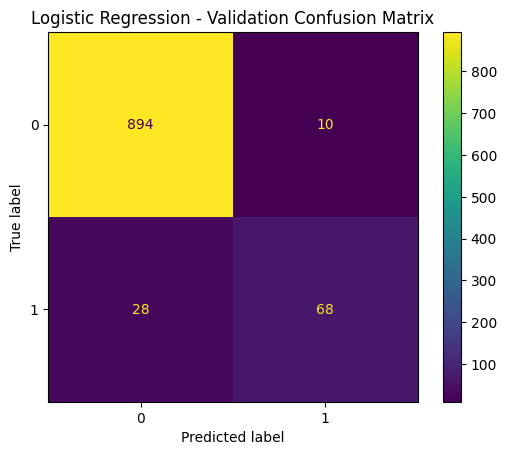

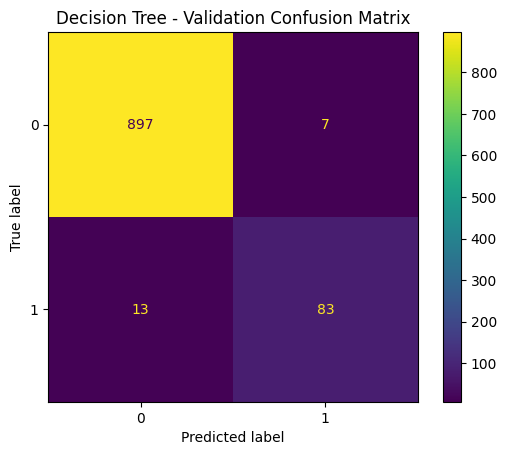

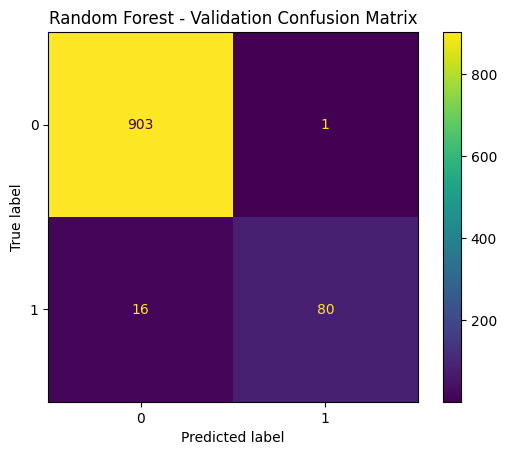

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        model.predict(X_val)
    )

    plt.title(f'{name} - Validation Confusion Matrix')
    plt.show()

##THRESHOLDS

In [129]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.2, 0.81, 0.05)

threshold_results_rf = []

for threshold in thresholds:

    y_pred = (y_val_prob_rf >= threshold).astype(int)

    threshold_results_rf.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    })

threshold_results_rf = pd.DataFrame(threshold_results_rf)

threshold_results_rf

,Threshold,Precision,Recall,F1
0,0.20,0.814159,0.958333,0.880383
1,0.25,0.882353,0.937500,0.909091
2,0.30,0.909091,0.937500,0.923077
3,0.35,0.946237,0.916667,0.931217
4,0.40,0.954545,0.875000,0.913043
5,0.45,0.964286,0.843750,0.900000
6,0.50,0.987654,0.833333,0.903955
7,0.55,0.987500,0.822917,0.897727
8,0.60,0.986301,0.750000,0.852071
9,0.65,0.985294,0.697917,0.817073


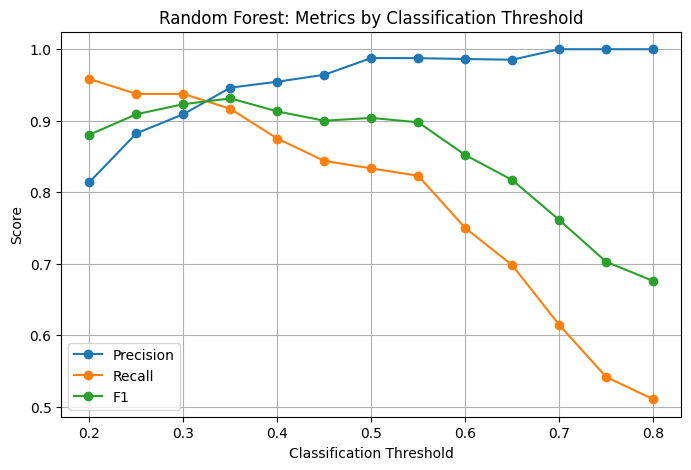

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_rf['Threshold'],
    threshold_results_rf['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results_rf['Threshold'],
    threshold_results_rf['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results_rf['Threshold'],
    threshold_results_rf['F1'],
    marker='o',
    label='F1'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Random Forest: Metrics by Classification Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [131]:
y_val_prob_tree = tree_model.predict_proba(X_val)[:, 1]

In [132]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.2, 0.81, 0.05)

threshold_results_tree = []

for threshold in thresholds:

    y_pred = (y_val_prob_tree >= threshold).astype(int)

    threshold_results_tree.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    })

threshold_results_tree = pd.DataFrame(threshold_results_tree)

threshold_results_tree

,Threshold,Precision,Recall,F1
0,0.20,0.913978,0.885417,0.899471
1,0.25,0.913978,0.885417,0.899471
2,0.30,0.913978,0.885417,0.899471
3,0.35,0.922222,0.864583,0.892473
4,0.40,0.922222,0.864583,0.892473
5,0.45,0.922222,0.864583,0.892473
6,0.50,0.922222,0.864583,0.892473
7,0.55,0.939759,0.812500,0.871508
8,0.60,0.939759,0.812500,0.871508
9,0.65,0.950617,0.802083,0.870056


In [133]:
rf_selected = threshold_results_rf[
    threshold_results_rf['Threshold'].isin([0.20, 0.25, 0.30, 0.35, 0.40, 0.50])
].copy()

tree_selected = threshold_results_tree[
    threshold_results_tree['Threshold'].isin([0.20, 0.25, 0.30, 0.35, 0.40, 0.50])
].copy()

rf_selected['Model'] = 'Random Forest'
tree_selected['Model'] = 'Decision Tree'

threshold_comparison = pd.concat(
    [rf_selected, tree_selected],
    ignore_index=True
)

threshold_comparison[
    ['Model', 'Threshold', 'Precision', 'Recall', 'F1']
]

,Model,Threshold,Precision,Recall,F1
0,Random Forest,0.20,0.814159,0.958333,0.880383
1,Random Forest,0.25,0.882353,0.937500,0.909091
2,Random Forest,0.30,0.909091,0.937500,0.923077
3,Random Forest,0.35,0.946237,0.916667,0.931217
4,Decision Tree,0.20,0.913978,0.885417,0.899471
5,Decision Tree,0.25,0.913978,0.885417,0.899471
6,Decision Tree,0.30,0.913978,0.885417,0.899471
7,Decision Tree,0.35,0.922222,0.864583,0.892473


### Threshold Comparison

The threshold analysis shows a trade-off between Precision and Recall
for both tree-based models.

For the Random Forest:

- At a threshold of 0.30, Recall reaches 93.75% while Precision remains
  at 90.91%.
- At a threshold of 0.35, Precision increases to 94.62%, while Recall
  decreases slightly to 91.67%.
- The F1-score increases from 92.31% at threshold 0.30 to 93.12% at
  threshold 0.35.

For the Decision Tree:

- The highest Recall observed in the tested thresholds is 88.54%.
- At thresholds between 0.20 and 0.30, Precision is 91.40% and Recall
  is 88.54%.

These results show that the Random Forest provides a higher Recall at
the tested thresholds while also maintaining high Precision.

##4. Candidate Model Selection

### Selection Approach

Model selection is based on:

1. Generalization performance between the training and validation sets.
2. Precision, Recall and F1-score on the validation set.
3. The Precision–Recall trade-off under different classification
   thresholds.
4. The business consideration of reducing False Negatives.

### Candidate Model

Based on the validation analysis, Random Forest is selected as the
candidate model for final evaluation.

At a threshold of 0.30, the Random Forest achieves:

- Precision: 90.91%
- Recall: 93.75%
- F1-score: 92.31%

This threshold provides a higher Recall than the default threshold of
0.50, while maintaining Precision above 90%.

The selected model and threshold will be evaluated once on the
previously unseen test set.

In [134]:
final_model = rf_model
final_threshold = 0.30

In [135]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

In [136]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

final_test_results = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    'Recall': recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    'F1': f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        y_test_prob
    ),
    'PR-AUC': average_precision_score(
        y_test,
        y_test_prob
    )
}

final_test_results

{'Accuracy': 0.983,
 'Precision': 0.8761904761904762,
 'Recall': 0.9583333333333334,
 'F1': 0.9154228855721394,
 'ROC-AUC': np.float64(0.9986057337758112),
 'PR-AUC': np.float64(0.9879824922582302)}

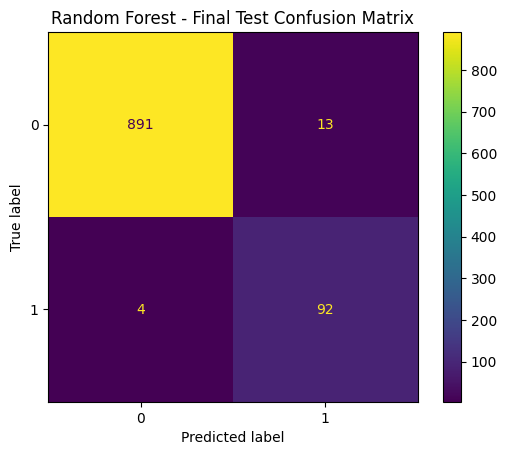

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title(
    'Random Forest - Final Test Confusion Matrix'
)

plt.show()

## 5. Final Test Evaluation

After selecting the Random Forest model with a classification threshold
of 0.30 based on the validation set, the final configuration was
evaluated once on the previously unseen test set.

The test set was not used during model or threshold selection.

### Final Test Performance

| Metric | Test Score |
|---|---:|
| Accuracy | 98.30% |
| Precision | 87.62% |
| Recall | 95.83% |
| F1-score | 91.54% |
| ROC-AUC | 99.86% |
| PR-AUC | 98.80% |

### Confusion Matrix

The final confusion matrix contains:

- True Negative (TN): 891
- False Positive (FP): 13
- False Negative (FN): 4
- True Positive (TP): 92

### Interpretation

The model identifies 92 out of 96 customers who actually accepted
the personal loan, resulting in a Recall of 95.83%.

Only 4 positive cases were missed by the model.

On the other hand, the model generated 13 False Positives, meaning
these customers were predicted as potential loan customers but did
not actually accept the loan.

This reflects the trade-off introduced by using a lower classification
threshold of 0.30: Recall is prioritized by identifying more potential
customers, while Precision decreases because more customers are
classified as positive.

## 6. Conclusion

This project developed a supervised binary classification workflow
to predict whether a customer would accept a personal loan offer.

The analysis followed the process:

Business Problem
→ Data Understanding
→ Data Quality Check
→ EDA
→ Train/Validation/Test Split
→ Baseline
→ Model Comparison
→ Overfitting Check
→ Threshold Analysis
→ Final Test Evaluation

The target variable was highly imbalanced, so accuracy was not used
as the only evaluation metric.

Three classification models were evaluated. Based on the validation
analysis and the business consideration of reducing False Negatives,
Random Forest was selected as the candidate model.

A classification threshold of 0.30 was selected to increase Recall
relative to the default threshold of 0.50.

On the previously unseen test set, the final configuration achieved:

- Accuracy: 98.30%
- Precision: 87.62%
- Recall: 95.83%
- F1-score: 91.54%
- ROC-AUC: 99.86%
- PR-AUC: 98.80%

These results indicate that the final configuration identified
92 out of 96 customers who actually accepted the loan, resulting
in a Recall of 95.83%.

The model achieved a Precision of 87.62%, with 13 False Positives
and 4 False Negatives on the test set.
These results indicate that the final configuration was able to
identify most customers who actually accepted the loan, while also
maintaining high Precision.

However, the threshold was selected based on the validation results
and a qualitative business consideration. A formal cost-based
threshold selection would require quantified business costs for
False Positives and False Negatives.